# Redes Convolucionales con PyTorch

Usaremos CIFAR-10. https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.CIFAR10.html#torchvision.datasets.CIFAR10

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Load data

In [3]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
batch_size = 32

# Me basé en https://www.geeksforgeeks.org/python/how-to-load-cifar10-dataset-in-pytorch/
# Nota: TV = TorchVision
train_as_seen_in_tv = torchvision.datasets.CIFAR10(root='./datasets/cifar10', train=True, download=True, transform=torchvision.transforms.ToTensor())
test_as_seen_in_tv = torchvision.datasets.CIFAR10(root='./datasets/cifar10', train=False, download=True, transform=torchvision.transforms.ToTensor())

train_loader_from_tv_at_ONLY_32_batch = DataLoader(train_as_seen_in_tv, batch_size=batch_size, shuffle=True)
test_loader_from_tv_at_ONLY_32_batch = DataLoader(test_as_seen_in_tv, batch_size=batch_size, shuffle=False)

/home/david/computational-intelligence/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Preparing dataset

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [4]:
def get_batch_accuracy(output, y):
    pred = output.argmax(dim=1)
    return (pred == y).sum().item() # no me haga mucho caso pero creo que esta función estaba mal porque N es el tamaño del dataset completo y esto es un batch, incluso acertando las 32 [sic] instancias nos daría un número irremediablemente menor a 100%

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [5]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        total_correctas = 0
        total_muestras = 0
        
        test_loss = 0.0
        test_total_correctas = 0
        test_total_muestras = 0
        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            total_correctas += get_batch_accuracy(outputs, y_batch)
            total_muestras += y_batch.size(0)

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = total_correctas / total_muestras
        
        _model.eval()

        with torch.no_grad():
            for x, y in _test_loader:
                x = x.to(device)
                y = y.to(device)

                output = _model(x)
                loss = _criterion(output, y)

                test_loss += loss.item() * x.size(0)
                test_total_correctas += get_batch_accuracy(output, y)
                test_total_muestras += y.size(0)

        epoch_test_loss = test_loss / len(_test_loader.dataset)
        epoch_test_acc = test_total_correctas / test_total_muestras

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}"
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(epoch_test_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [6]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_total_correctas = 0
    test_total_muestras = 0
    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device)
            y = y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_total_correctas += get_batch_accuracy(output, y)
            test_total_muestras += y.size(0)

    return (test_loss / len(_test_loader.dataset)), (test_total_correctas / test_total_muestras)

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [7]:
model_cnn = {
    1: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 64, 3, stride=2, padding=1),
        # x: ¿por qué 64 filtros?
        # homero: para más poder
        nn.BatchNorm2d(64), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(64, 64, 3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 128, 3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Dropout(.2),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256, 256, 3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(1024, 256),
        nn.Dropout(.3),
        nn.ReLU(),
        nn.Linear(256, 10)
    ),
    2: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 12, 3, stride=2, padding=1),
        # x: ¿por qué 12 filtros?
        # homero: para menos poder
        nn.BatchNorm2d(12), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(12, 12, 3, padding=1),
        nn.BatchNorm2d(12),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(12, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Conv2d(24, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Dropout(.2),
        nn.MaxPool2d(2),

        nn.Conv2d(24, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.Conv2d(48, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(192, 96),
        nn.Dropout(.3),
        nn.ReLU(),
        nn.Linear(96, 10)
    ),
    3: nn.Sequential(
        nn.Conv2d(IMG_CHANNELS, 12, 3, padding=1),
        # x: ¿por qué 12 filtros?
        # homero: para menos poder
        nn.BatchNorm2d(12), # esto debiera permitirnos un aprendizaje más fino: https://www.geeksforgeeks.org/deep-learning/what-is-batch-normalization-in-deep-learning/
        nn.ReLU(),
        nn.Conv2d(12, 12, 3, padding=1),
        nn.BatchNorm2d(12),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(12, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.Conv2d(24, 24, 3, padding=1),
        nn.BatchNorm2d(24),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(24, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.Conv2d(48, 48, 3, padding=1),
        nn.BatchNorm2d(48),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(768, 10)
    ),
}

for k in model_cnn.keys():
    model_cnn[k] = model_cnn[k].to(device)

In [8]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
cnn_res = {
    1: None,
    2: None,
    3: None
}
for k in model_cnn.keys():
    optimizer = Adam(model_cnn[k].parameters()) # son los mismos de todas fromas
    cnn_res[k] = train(model_cnn[k], train_loader_from_tv_at_ONLY_32_batch, test_loader_from_tv_at_ONLY_32_batch, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:06<00:00,  6.31s/epoch, test_acc=0.7660, test_loss=0.8913, train_acc=0.9270, train_loss=0.2032]


In [9]:
cnn_test_loss = {
    1: None,
    2: None,
    3: None
}
cnn_test_acc = {
    1: None,
    2: None,
    3: None
}
for k in model_cnn.keys():
    cnn_test_loss[k], cnn_test_acc[k] = test(model_cnn[k], test_loader_from_tv_at_ONLY_32_batch, loss_function)

In [10]:
comparison_dict = {
    'Modelo': [f'CNN {k}' for k in model_cnn.keys()],
    'Pérdida de prueba': [cnn_test_loss[k] for k in model_cnn.keys()],
    'Exactitud de prueba': [cnn_test_acc[k] for k in model_cnn.keys()]
}

pd.DataFrame(comparison_dict)

,Modelo,Pérdida de prueba,Exactitud de prueba
0,CNN 1,0.807981,0.8100
1,CNN 2,0.821403,0.7232
2,CNN 3,0.891283,0.7660


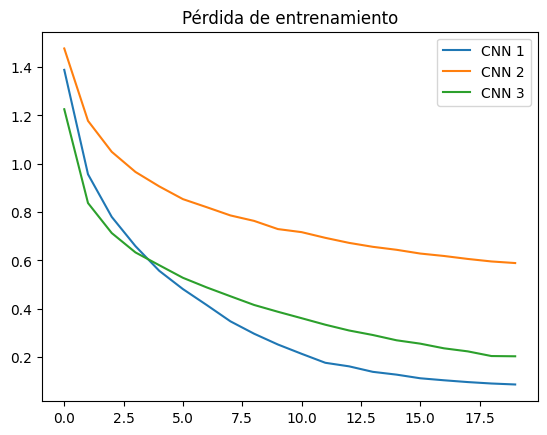

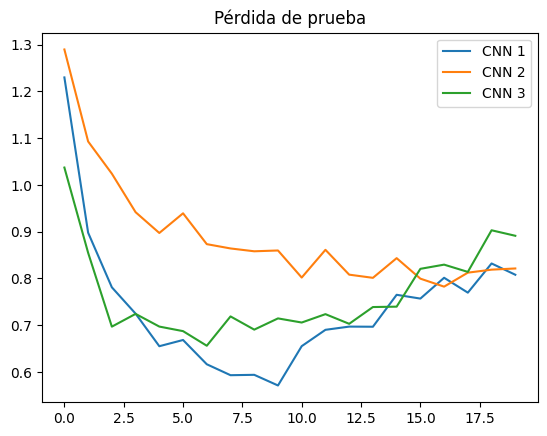

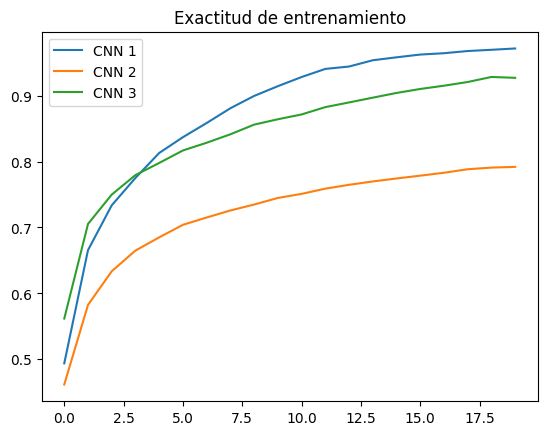

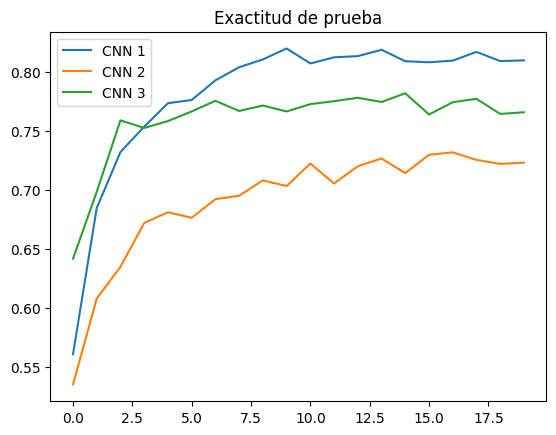

In [11]:
epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('train_loss'), label=f"CNN {k}")
plt.legend()
plt.title("Pérdida de entrenamiento")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('test_loss'), label=f"CNN {k}")
plt.legend()
plt.title("Pérdida de prueba")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('train_acc'), label=f"CNN {k}")
plt.legend()
plt.title("Exactitud de entrenamiento")
plt.show()

epochs_range = range(epochs)
for k in model_cnn.keys():
    plt.plot(epochs_range, cnn_res[k].get('test_acc'), label=f"CNN {k}")
plt.legend()
plt.title("Exactitud de prueba")
plt.show()

# Sobre las arquitecturas...
Definí tres arquitecturas de redes convolucionales que comparten épocas e hiperparámetros, pero que difieren en unas sutilezas. Primero que nada, la primer arquitectura que definí es, en mi opinión, aberrantemente compleja. Le hice a la entrada, evidentemente compatible con los canales de imágenes en todo color, pero le apliqué 64 filtros y le dejé un stride de 2. Posteriormente le apliqué algo que leí en Geeks for Geeks de batch normalization, con los 64 filtros, y tras aplicarle ReLU, hice una convolución bidimensional de los 64 filtros y volví a aplicar la normalización de batch. Escapa a mi comprensión realmente si tiene algún efecto estar repitiendo la normalización, pero a como yo lo entendí, tiene sentido porque tras la convolución los valores se ven alterados. Bien, tras aplicar un max pool bidimensional, repetimos este proceso aumentando gradualmente los filtros hasta llegar a 256 filtros en la imagen y posteriormente los aplanamos, lo que nos da para la siguiente capa lineal 1024 características que luego transformamos a 256 de salida, le hacemos un drop out a la red del 30%. Previamente ya habíamos aplicado un drop out del 20%. Y finalmente hacemos ReLU y una última capa lineal de 256 hacia 10, que son las etiquetas. Bien, eso por un lado. Por el otro, la segunda arquitectura se le parece en base, pero es más ligera, utiliza menos número de filtros, mantiene el stride y los dropout. Realmente es eso, o sea, difieren en complejidad. Y la última, la tercera, se parece a la segunda en cantidad de filtros, pero ya no tiene el stride y, aparte, en la última etapa, tras hacer el aplanamiento, aplicamos una única capa lineal de la cual posteriormente tomamos las etiquetas. Es decir, reducimos en un paso el procesamiento. Y, para sorpresa de nadie salvo mía, los resultados fueron que, en prueba, los modelos tenían: la primera arquitectura, la más compleja, 81% de exactitud; el segundo, 73%; y el tercero, 76%. Lo que me parece razonable hasta que, bueno, observas que en el entrenamiento fueron bastante progresivos y en la prueba fueron caóticos. Y, asimismo, cuando se trata de exactitud en entrenamiento, la primera y segunda arquitectura tienen overfitting. Eso sí, no lo puedo ignorar ni maquillar. En la prueba tienen una diferencia de alrededor del 10% en desempeño. Es más o menos. Entonces, ¿qué nos dice esto? Que nuestra arquitectura se aprendió los datos, pero tiene una muy buena exactitud. Eso creo que es mérito del trabajo que hice aquí, porque, o sea, estamos hablando de una exactitud para la arquitectura más compleja del 81%. Es decir, primero que nada, es mejor que adivinar. Segundo, por cada 10 imágenes de un venado, el modelo va a atinar 8, o por cada 10 imágenes de un perro, el modelo va a atinar 8, y así. Aunque ciertamente no es idóneo, y más adelante, cuando evalúe el modelo elegido, veremos por qué.

In [12]:
mejor_convulsión = model_cnn[max(cnn_test_acc, key=cnn_test_acc.get)]

In [13]:
transformación_para_inferencia_arbitraria = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((32,32)), #wonka dijo redimensiónenlo (¿?) ... de hecho, es curioso porque al menos dos de los afectados por los doings de wonka fueron de algún modo u otro redimensionados
        torchvision.transforms.ToTensor()
    ]
)

def predecir_en_cifar_10(ruta, modelo=mejor_convulsión, mostrar=False):
    modelo.eval()
    imagen = Image.open(ruta).convert("RGB")
    if(mostrar): imagen.show()
    características = transformación_para_inferencia_arbitraria(imagen).unsqueeze(0).to(device)
    
    with torch.no_grad():
        salida = modelo(características)
        adivinación = salida.argmax(dim=1).item()
        
    return train_as_seen_in_tv.classes[adivinación]

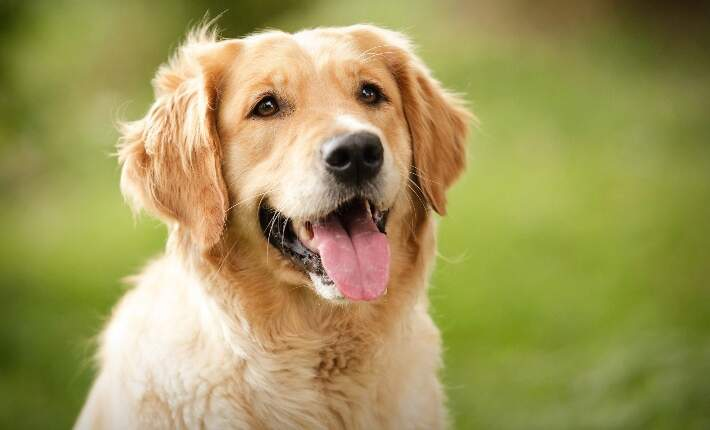

Tu imagen se parece a dog, ¿verdad que sí le atiné?


In [14]:
adivinación_inferencil = predecir_en_cifar_10(input("Ruta a la imagen: "), mostrar=True)
print(f"Tu imagen se parece a {adivinación_inferencil}, ¿verdad que sí le atiné?")

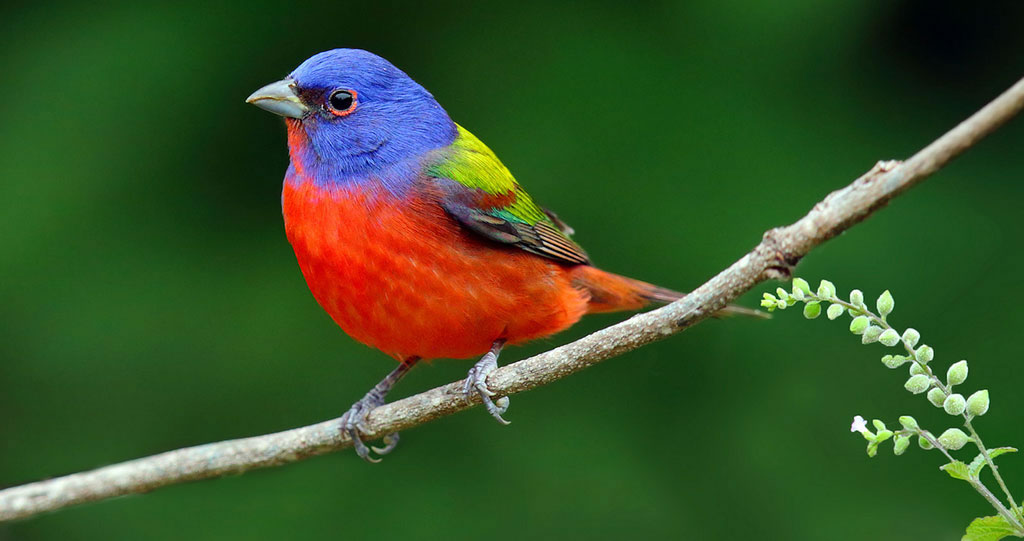

Tu imagen se parece a bird, ¿verdad que sí le atiné?


In [15]:
adivinación_inferencil = predecir_en_cifar_10(input("Ruta a la imagen: "), mostrar=True)
print(f"Tu imagen se parece a {adivinación_inferencil}, ¿verdad que sí le atiné?")

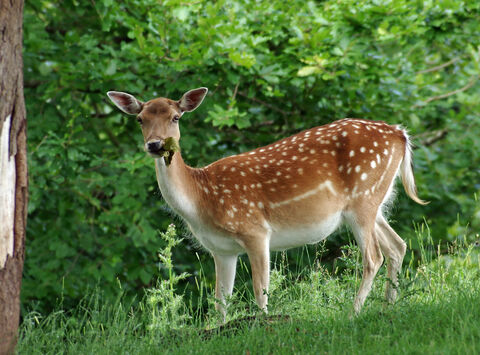

Tu imagen se parece a deer, ¿verdad que sí le atiné?


In [16]:
adivinación_inferencil = predecir_en_cifar_10(input("Ruta a la imagen: "), mostrar=True)
print(f"Tu imagen se parece a {adivinación_inferencil}, ¿verdad que sí le atiné?")

# Sobre el mejor modelo...
El mejor modelo elegido fue el que tiene la mejor exactitud de prueba, que como vimos en el punto anterior, fue indiscutiblemente la primera arquitectura, la más compleja y sencillamente la que presenta más overfitting. Pero, bajo el compromiso de hacerlo notorio, si bien tiene overfitting, es muy superior en exactitud a la segunda y a la tercera arquitectura que diseñé. Y personalmente me quedo con esa. ¿Se aprendió bastante de los datos? Sí. Pero también pienso yo que lo justifica el tener por arriba del 80% de aciertos y que en el mundo real los objetos generalmente, no digo que siempre, pero generalmente se parecen entre sí visualmente. Es decir, sabemos identificar las cosas porque se parecen mucho entre sí, salvo cuando ya tratamos con conceptos, como qué es una silla o una mesa. Pero en lo más amplio, por ejemplo, en los animales, los animales tienden a parecerse entre sí cuando son de un mismo grupo, al menos. Entonces, pienso que para este escenario específico, a diferencia de otros escenarios donde estamos lidiando sobre datos numéricos o abstractos, como compras y demás, en este caso muy específico, no penalizaría yo tan fuertemente el overfitting, pero sí tenemos que reconocer que existe y que va a errar. Y de eso es de lo que quiero hablar a continuación. El modelo tiene una exactitud de prueba altísima y, sin embargo, tiene una limitante muy drástica. Mientras estuve haciéndole pruebas, me di cuenta de que confunde el 20% de las imágenes; se debe mayoritariamente a la resolución de entrada. 32x32 píxeles es absurdamente poco. Y con… así tuviera 1% de error, me parece que es complicado que acierte en objetos y animales, sobre todo animales, que no son normativamente homogéneos a los datos de entrada de entrenamiento. ¿A qué me refiero con esto? Que va a confundir gatos calicó con perros, que va a confundir señales de tránsito por el fondo con pájaros rojos, que va a confundir balones de básquetbol con gatos naranjas y un sinfín de cosas. Porque creo estar en lo correcto al señalar que, al tener una resolución tan baja, el modelo depende demasiado de los canales de color para las inferencias. Entonces hace asociaciones que pienso yo serían de lo último que pensaríamos al identificar objetos. Al menos nosotros, como seres humanos, pienso yo, primero nos fijamos en la forma y después en el color. Si ha visto de esos abundantes memes sobre de qué color era tal, pues sabrá a lo que me refiero. Y es eso. Por cuestiones de la actividad, pues sí, lo tuve que manejar en color, pero a mí me hubiera gustado manejar escala de grises y o realizar un preprocesamiento de detección de bordes. Sé que para lo primero, pues no, no estaba permitido, pero para lo segundo no lo hice bajo la noción de que, bueno, teníamos que entrenar el modelo y que el modelo hiciera el trabajo, no dejarle hecha papilla la tarea. Pero sí, así que me crucé con imágenes en donde me los clasificaba mal. Y ese 20%, aunque pequeño, pienso yo que es un 20% muy abundante, porque el conjunto de prueba, cualesquiera que sean las imágenes, tuvo un proceso de selección similar al conjunto de entrenamiento. Entonces, son imágenes que en otro contexto llamaríamos genéricas. O sea, es lo que está en el imaginario colectivo y falla este modelo en las peculiaridades, y el tema está en que nuestro mundo es un mundo de peculiaridades.

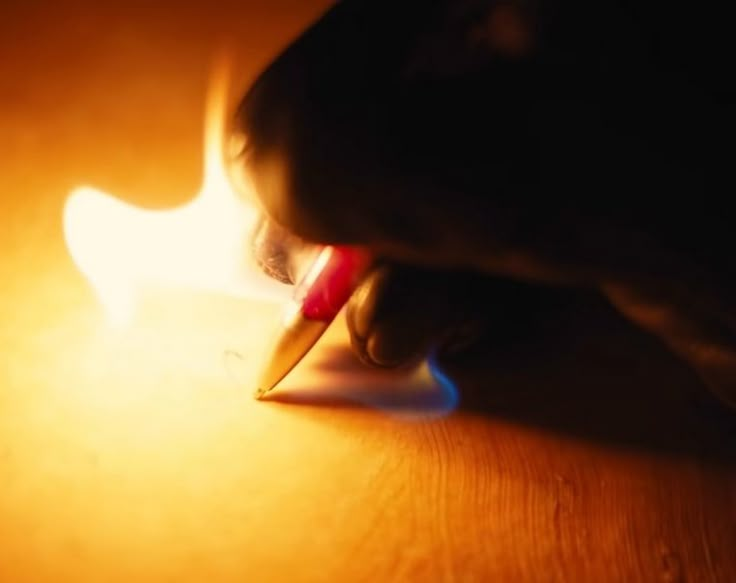

Tu imagen se parece a cat, ¿verdad que sí le atiné?


In [17]:
adivinación_inferencil = predecir_en_cifar_10(input("Ruta a la imagen: "), mostrar=True)
print(f"Tu imagen se parece a {adivinación_inferencil}, ¿verdad que sí le atiné?")